In [344]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [345]:
from pathlib import Path

for p in Path("..").rglob("*.zip"):
    print(p)

..\Project 2- E- Commerce Analysis\Data\archive.zip


In [346]:
import pandas as pd

df = pd.read_csv("Data/archive.zip")
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


# Check Shape 

In [347]:
df.shape

(9994, 13)

# Check Columns 

In [348]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

# check data types

In [349]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


# Data Cleaning

In [350]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [351]:
df.duplicated().sum()

17

In [352]:
df.drop_duplicates(inplace=True)

In [353]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [354]:
df.describe()
print("Total Sales:", df['Sales'].sum())
print("Total Profit:", df['Profit'].sum())

Total Sales: 2296195.5903
Total Profit: 286241.4226


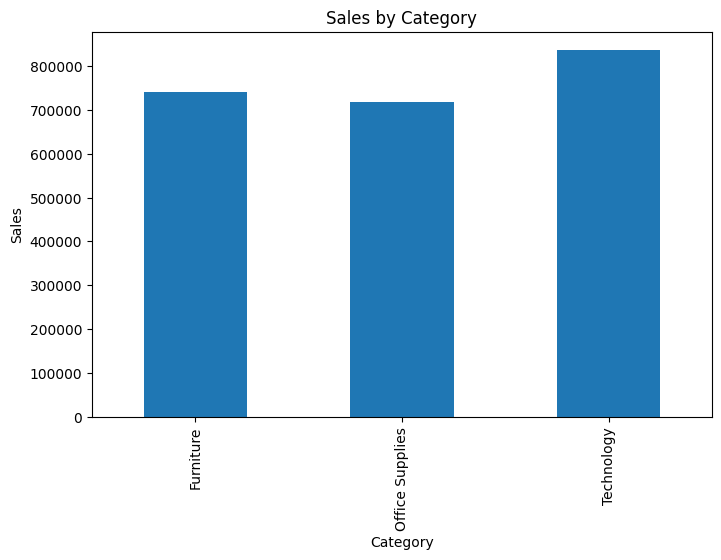

In [355]:
sales_by_category = df.groupby('Category')['Sales'].sum()

sales_by_category.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

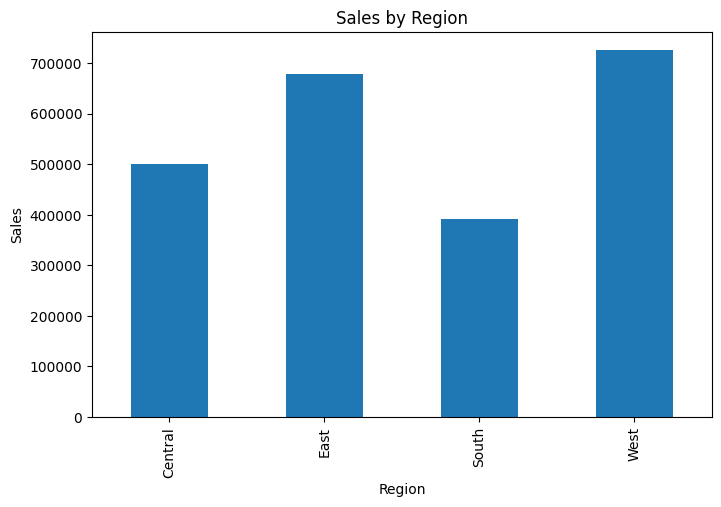

In [356]:
sales_by_region = df.groupby('Region')['Sales'].sum()

sales_by_region.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

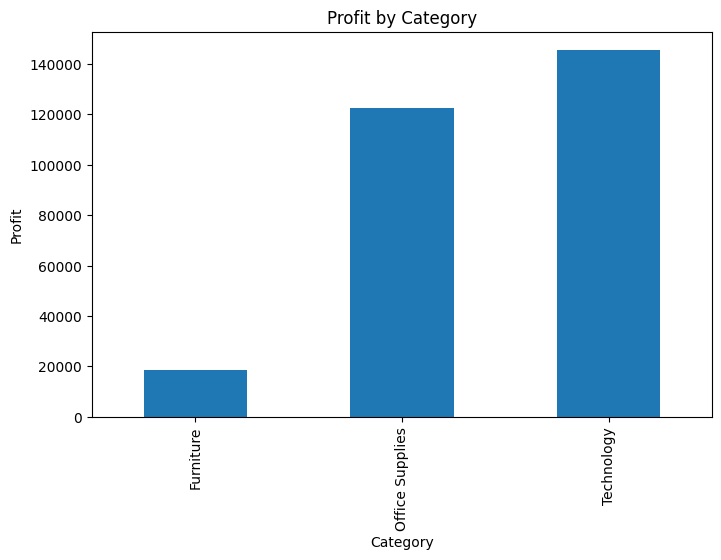

In [357]:
profit_by_category = df.groupby('Category')['Profit'].sum()

profit_by_category.plot(kind='bar', figsize=(8,5))
plt.title("Profit by Category")
plt.ylabel("Profit")
plt.show()

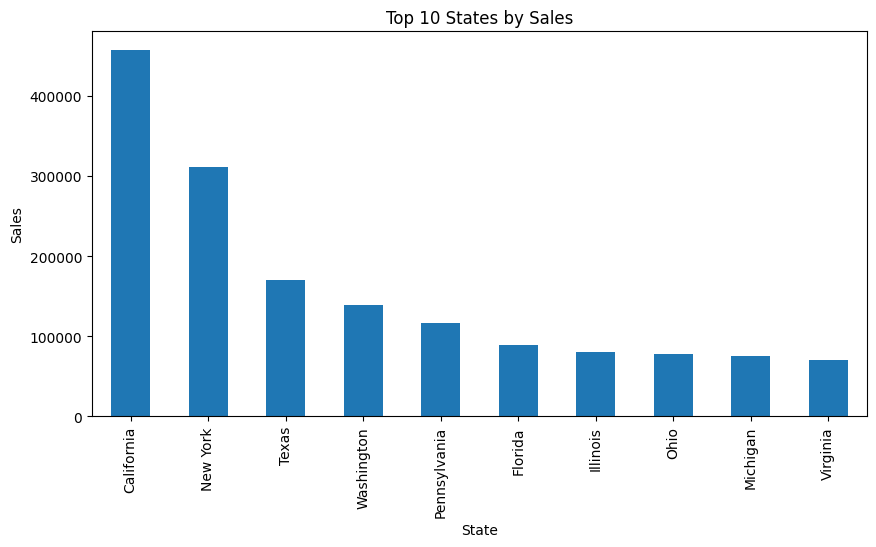

In [358]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

top_states.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 States by Sales")
plt.ylabel("Sales")
plt.show()

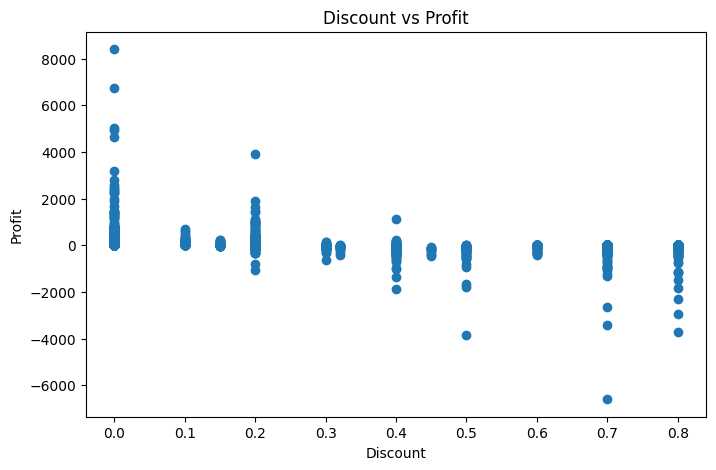

In [359]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['Discount'], df['Profit'])
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()

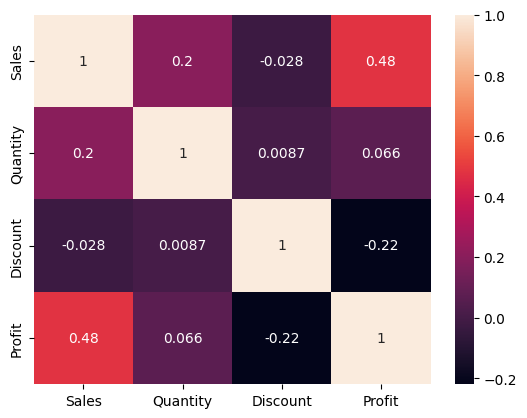

In [360]:
import seaborn as sns

corr = df[['Sales','Quantity','Discount','Profit']].corr()

sns.heatmap(corr, annot=True)
plt.show()

In [361]:
print("Total Sales:", df['Sales'].sum())
print("Total Profit:", df['Profit'].sum())
print("Total Quantity:", df['Quantity'].sum())

Total Sales: 2296195.5903
Total Profit: 286241.4226
Total Quantity: 37820


In [362]:
for col in ['Ship Mode','Segment','Region','Category','Sub-Category']:
    print(f"\n{col}")
    print(df[col].value_counts())


Ship Mode
Standard Class    5955
Second Class      1943
First Class       1537
Same Day           542
Name: Ship Mode, dtype: int64

Segment
Consumer       5183
Corporate      3015
Home Office    1779
Name: Segment, dtype: int64

Region
West       3193
East       2845
Central    2319
South      1620
Name: Region, dtype: int64

Category
Office Supplies    6012
Furniture          2118
Technology         1847
Name: Category, dtype: int64

Sub-Category
Binders        1522
Paper          1359
Furnishings     956
Phones          889
Storage         846
Art             795
Accessories     775
Chairs          615
Appliances      466
Labels          363
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: Sub-Category, dtype: int64


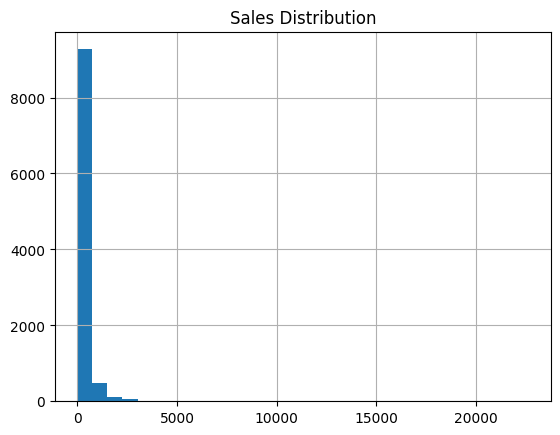

In [363]:
import matplotlib.pyplot as plt

df['Sales'].hist(bins=30)
plt.title("Sales Distribution")
plt.show()

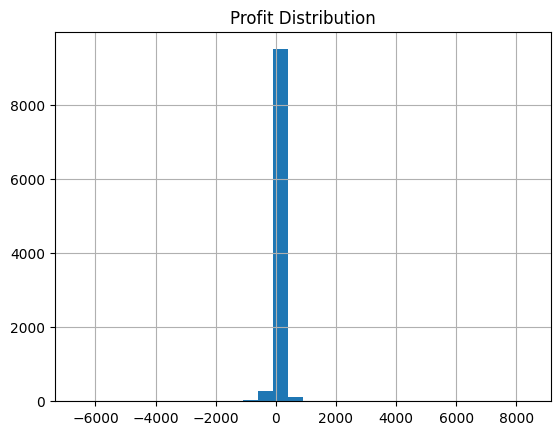

In [364]:
df['Profit'].hist(bins=30)
plt.title("Profit Distribution")
plt.show()

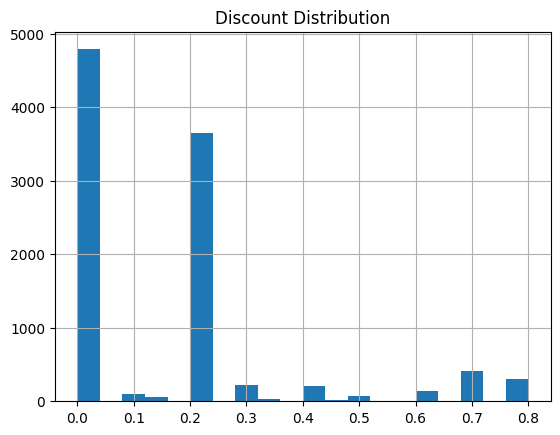

In [365]:
df['Discount'].hist(bins=20)
plt.title("Discount Distribution")
plt.show()

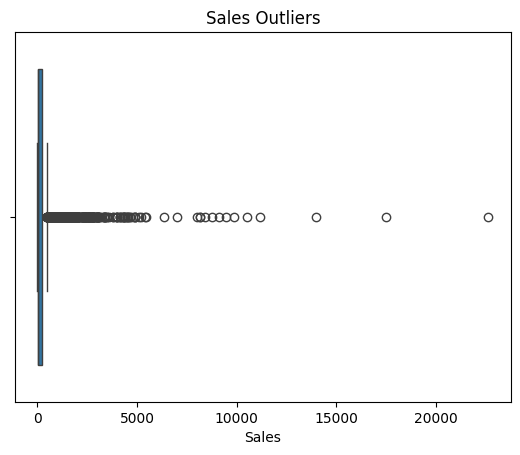

In [366]:
import seaborn as sns

sns.boxplot(x=df['Sales'])
plt.title("Sales Outliers")
plt.show()

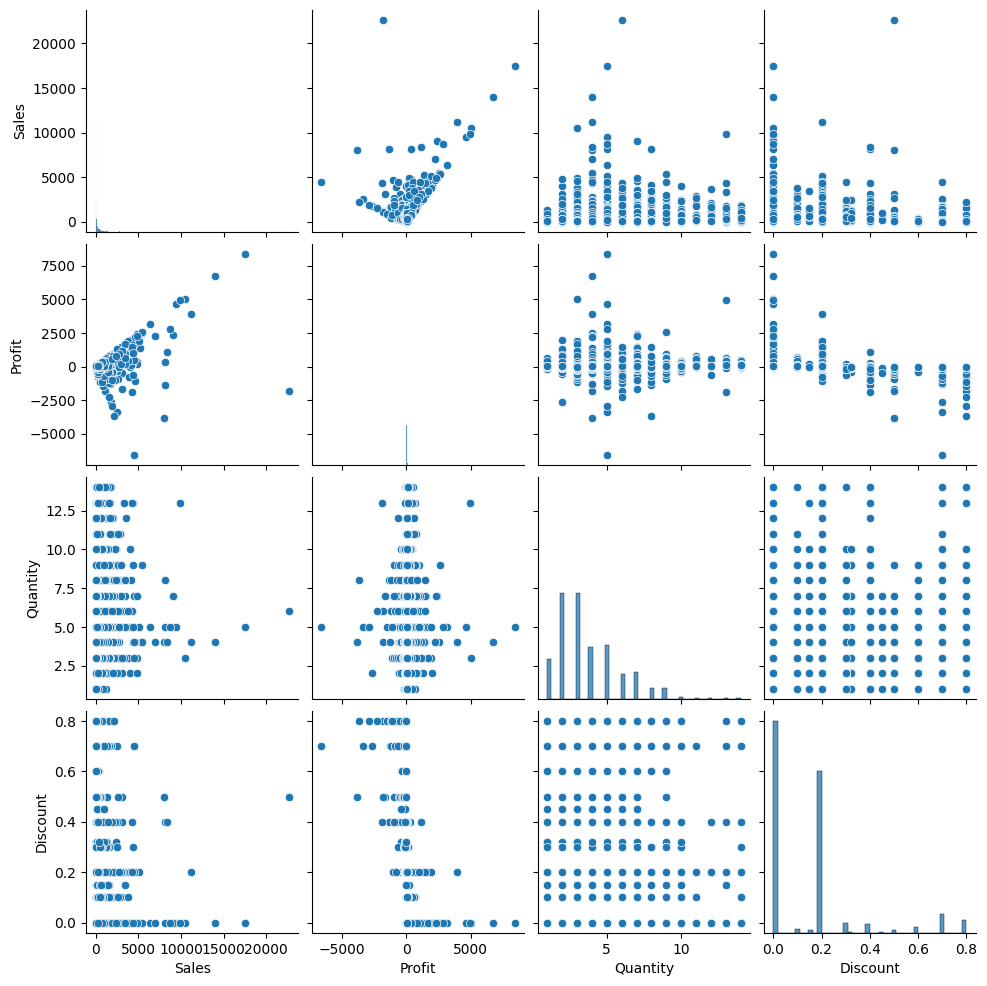

In [367]:
import seaborn as sns

sns.pairplot(df[['Sales','Profit','Quantity','Discount']])
plt.show()